# 06. Customer Activity Map (CAM) 분석

05에서 클러스터별 LDA 토픽 키워드를 추출했습니다.
이번 단계에서는 각 토픽을 **Action(행동 주제)**으로 정의하고, Actor × Action 조합별 **만족도(Satisfaction)**와 **중요도(Importance)**를 정량화하여 **개선 우선순위(Opportunity Score)**를 도출합니다.

> CAM = Customer Activity Map: 고객 유형(Actor)별 행동 주제(Action)를 매핑하고, 각 조합의 개선 기회를 정량적으로 평가하는 CX 분석 프레임워크

**CAM결과** 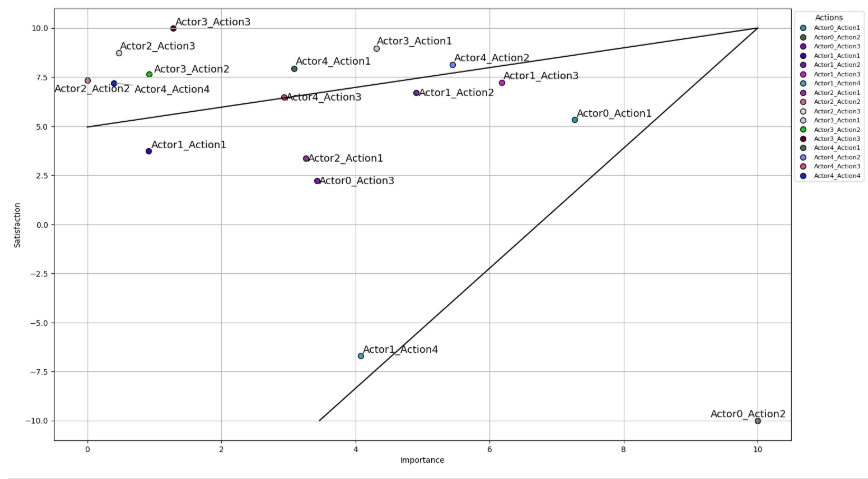

## 1. 데이터 준비

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# 클러스터별 LDA 결과 CSV 로드 (각 팀원이 action_cluster를 부여한 상태)
df0 = pd.read_csv('df_cluster_0_topic1.csv', encoding = 'utf-8-sig')
df1 = pd.read_csv('Cluster1_4.csv', encoding = 'utf-8-sig', index_col = 0)
df2 = pd.read_csv('df_cluster2.csv', encoding = 'utf-8-sig')
df3 = pd.read_csv('dog_cluster3.csv', encoding = 'utf-8-sig', index_col = 0)
df4 = pd.read_csv('dog_cluster4.csv', encoding = 'utf-8-sig', index_col = 0)

# 컬럼명 통일
df_0 = df0.rename(columns={'cluster_1400_7': 'cluster'})
new_order2 = ['clean_content', 'cluster', 'tagged_review', 'action_cluster']
df_0 = df_0[new_order2]

df_1 = df1.rename(columns={'action_cluster4': 'action_cluster'})
df_1 = df_1.rename(columns={'cluster_1400_7': 'cluster'})

df_2 = df2.rename(columns={'lp_label': 'cluster'})
new_order1 = ['clean_content', 'cluster', 'tagged_review', 'action_cluster']
df_2 = df_2[new_order1]
df_2['cluster'] = 2

df_3 = df3.drop('title', axis = 1)
df_3 = df_3.rename(columns={'cluster_1400_7': 'cluster'})
new_order = ['clean_content', 'cluster', 'tagged_review', 'action_cluster']
df_3 = df_3[new_order]

df_4 = df4.drop(['title', 'clean_content_y'], axis = 1)
df_4 = df_4.rename(columns={'clean_content_x': 'clean_content'})
df_4['cluster'] = 4
new_order = ['clean_content', 'cluster', 'tagged_review', 'action_cluster']
df_4 = df_4[new_order]

# 통합
df = pd.concat([df_0, df_1, df_2, df_3, df_4], axis = 0).reset_index(drop=True)
print(f'통합 데이터: {len(df):,}건')
df.cluster.value_counts().sort_index()

## 2. Actor × Action 정의 및 요약

05의 토픽 키워드를 바탕으로 각 클러스터(Actor)의 토픽을 Action으로 정의합니다.

| Actor | 소제목 | Action 1 | Action 2 | Action 3 | Action 4 |
|-------|--------|----------|----------|----------|----------|
| 0 | 헬스케어형 펫 보호자 | 일상 건강 관리 질문 | 수술/재활/병원 질문 | 영양제·보조제 챙김 | - |
| 1 | 초보 펫 보호자 | 질병 예방·정보 검색 | 배변·위생 걱정 | 용품 구매·리뷰 | 피부·털 관리 |
| 2 | 펫과 동반 여행 보호자 | 여행 경험 공유 | 비행기 탑승 | 숙소·프리미엄 경험 | - |
| 3 | 반려동물 산책 담당 | 산책·날씨 고민 | 놀이 장소 | 사진·공유 | - |
| 4 | 행동 교정 보호자 | 분리 불안·교정 | 맡길 곳 | 이웃 충돌·훈련 | 이별·사별 감정 |

## 3. Satisfaction (감성분석)

SentiWord 감성사전을 활용하여 리뷰별 감성 점수를 산출하고, Actor × Action별 집계 후 정규화합니다.

**감성 점수 계산 방식:**
1. 리뷰 내 각 토큰의 polarity를 **합산** → 리뷰별 감성 점수
2. Actor × Action별 리뷰 감성 점수의 **평균** → Satisfaction 원점수
3. MinMaxScaler(-10 ~ 10)로 정규화

> 초기에는 Actor × Action별 집계도 합산으로 했으나, 리뷰 수가 많은 조합에 점수가 몰리는 현상이 발생하여 평균으로 수정했습니다.

In [ ]:
import json

# 감성사전 로드
with open('SentiWord_info.json', encoding='utf-8-sig') as f:
    senti = json.load(f)

sent_map = {s['word']: float(s['polarity']) for s in senti}
print(f'감성사전 단어 수: {len(sent_map):,}')

In [ ]:
# 리뷰별 감성 점수 (토큰 polarity 합산)
def sentiment_sum(token_list):
    return sum(float(sent_map.get(tok, 0)) for tok in token_list)

df['sentiment_sum'] = [sentiment_sum(tokens) for tokens in tqdm(df['tagged_review'])]
df[['clean_content', 'cluster', 'action_cluster', 'sentiment_sum']].head()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Actor × Action별 평균 감성 점수
sent_dict = {}
for actor in df['cluster'].unique():
    actor_df = df[df['cluster'] == actor]
    for action in actor_df['action_cluster'].unique():
        action_scores = actor_df.loc[actor_df['action_cluster'] == action, 'sentiment_sum']
        action_score = np.mean(action_scores)
        sent_dict[f'Actor{actor}_Action{action}'] = action_score

# MinMaxScaler 정규화 (-10 ~ 10)
data = np.array(list(sent_dict.values())).reshape(-1, 1)

scaler = MinMaxScaler(feature_range = (-10, 10))
transformed_data = scaler.fit_transform(data)

score_result = transformed_data.flatten().tolist()
score_result = [round(i, 4) for i in score_result]

for key, new_value in zip(sent_dict.keys(), score_result):
    sent_dict[key] = new_value

sents_df = pd.DataFrame(sent_dict.items(), columns = ['Action', 'Satisfaction'])


## 4. Importance (빈도 기반 중요도)

각 Actor × Action 조합의 리뷰 빈도 비율을 중요도로 정의합니다.

In [ ]:
from collections import Counter

# Actor × Action별 빈도
importance_check = []
for actor, action in zip(df['cluster'], df['action_cluster']):
    action_flag = 'Actor' + str(actor) + '_' + 'Action' + str(action)
    importance_check.append(action_flag)

frequency = Counter(importance_check)

# 빈도 비율 계산
importance_dict = dict()
total_count = sum(frequency.values())
for item, value in frequency.items():
    importance = (value / total_count) * 100
    importance_dict[item] = importance

# MinMaxScaler 정규화 (0 ~ 10)
data = np.array(list(importance_dict.values())).reshape(-1, 1)

scaler = MinMaxScaler(feature_range = (0, 10))
transformed_data = scaler.fit_transform(data)

score_result = transformed_data.flatten().tolist()
score_result = [round(i, 4) for i in score_result]

for key, new_value in zip(importance_dict.keys(), score_result):
    importance_dict[key] = new_value

# Satisfaction df에 Importance 추가
importance_list = []
for action in sents_df['Action']:
    importance_list.append(importance_dict[action])

sents_df['Importance'] = importance_list

## 5. Opportunity Score

중요도는 높지만 만족도가 낮은 영역 = 개선 기회가 큰 영역

```
Opportunity = Importance + Max(Importance - Satisfaction, 0)
```

In [ ]:
def Opportunity_score(satisfaction, importance):
    result = importance + max(importance - satisfaction, 0)
    return result

opportunity_list = []
for i, j in zip(sents_df['Satisfaction'], sents_df['Importance']):
    score_result = Opportunity_score(i, j)
    opportunity_list.append(score_result)

sents_df['Opportunity_score'] = opportunity_list
sents_df.sort_values('Opportunity_score', ascending=False)

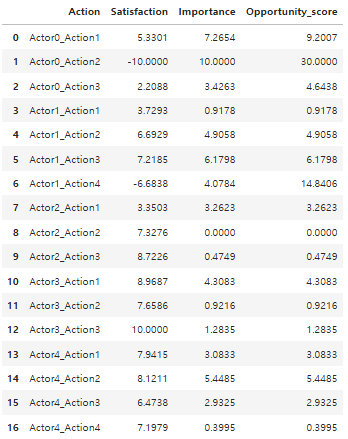

## 6. Opportunity Area 시각화

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

actions = sents_df.Action
colors = np.random.rand(len(actions), 3)
importance = sents_df.Importance
satisfaction = sents_df.Satisfaction

plt.figure(figsize = (17, 10))

# Action별 점찍기
for i, action in enumerate(actions):
    plt.scatter(importance[i], satisfaction[i], c = [colors[i]], 
                label = action, s = 50, edgecolors = 'black')

# 범례
plt.legend(title = 'Actions', fontsize = 8, title_fontsize = 10,
           loc = 'best', bbox_to_anchor = (1, 1))

# 축 타이틀 지정
plt.xlabel('Importance')
plt.ylabel('Satisfaction')

# 만족도 기준선
xdata = [0, 10]
ydata = [satisfaction.mean(), 10]
plt.plot(xdata, ydata, 'k-')

# 중요도 기준선
x_data = [importance.mean(), 10]
y_data = [-10, 10]
plt.plot(x_data, y_data, 'k-')

# 포인트에 텍스트 추가
texts = []
for i, action in enumerate(actions):
    texts.append(plt.text(importance[i], satisfaction[i], action, 
                          fontsize = 13, ha = 'left'))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray', lw = 1))
plt.grid(True)
plt.savefig('OpportunityArea.png', dpi = 300, bbox_inches = 'tight')
plt.show()

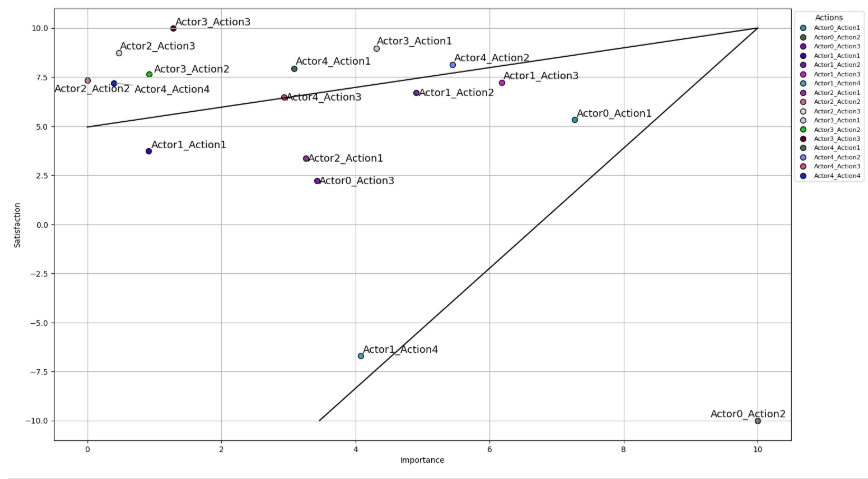

In [ ]:
sents_df.to_csv('opportunity.csv', encoding = 'utf-8-sig')
print('opportunity.csv 저장 완료')

## 결론

1. SentiWord 감성사전으로 리뷰별 감성 점수를 **합산** 방식으로 산출하고, Actor × Action별 **평균**으로 집계하여 Satisfaction을 계산
2. Actor × Action별 **리뷰 빈도 비율**을 Importance로 정의
3. `Opportunity = Importance + Max(Importance - Satisfaction, 0)` 공식으로 **개선 우선순위** 도출
4. **Actor 0(헬스케어형)과 Actor 1(초보 보호자)**에서 Opportunity Score가 가장 높음 → 개선 타겟 영역으로 선정